In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# ノートブックから見て、def_list フォルダへパスを通す
sys.path.append(os.path.abspath('../def_list'))

from run_classification_audition import run_classification_audition

# results = run_classification_audition(X, y)

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 50) 
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [96]:
# TotalChargesを数値に変換（空白はNaNにしてから0で埋めるのが定石）
df['TotalCharges_is_null'] = df['TotalCharges'].isnull()
df['duration'] = pd.cut(df['tenure'], bins=[0, 12, 24, 36, 48, 60, 72], labels=['1年未満', '1-2年', '2-3年', '3-4年', '4-5年', '5年以上'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
# 継続期間あたりの平均的な請求額（Total / tenure）
# 3. 契約サービス数（Yesの数を数える）
# InternetService, OnlineSecurity, TechSupport などの「Yes」をカウント
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Service_Count'] = (df[service_cols] == 'Yes').sum(axis=1)
df['Not_single_contract'] = df['Service_Count'].apply(lambda x: 2 if x > 1 else 1 if x == 1 else 0)

In [97]:
df_num = df.select_dtypes(include=['number'])
df_num.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Service_Count,Not_single_contract
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.067493,0.111907
tenure,0.016567,1.000000,0.247900,0.826178,0.494263,0.331396
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.724706,0.740396
TotalCharges,0.103006,0.826178,0.651174,1.000000,0.744827,0.583011
Service_Count,0.067493,0.494263,0.724706,0.744827,1.000000,0.858591
Not_single_contract,0.111907,0.331396,0.740396,0.583011,0.858591,1.000000


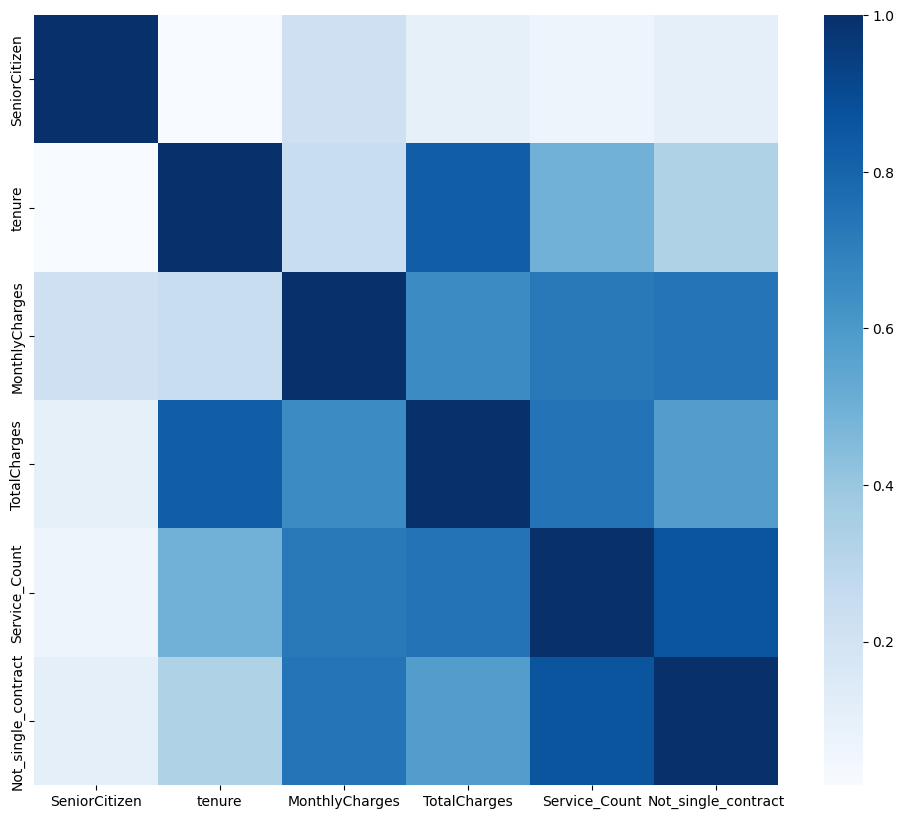

In [98]:
import seaborn as sns
# データの相関をチェック
# 数値データのみを抽出して相関行列を表示
corr_matrix = df_num.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='Blues')
plt.show()

In [99]:
X = df.drop(columns=['customerID', 'Churn']) # ヒント（説明変数）
y = df['Churn'].map({'Yes': 1, 'No': 0}) # 答え（目的変数）を0/1に変換
# こちらの方が実務でよく見る「文字列の列名リスト」を自動で作る技
obj_cols = X.select_dtypes(include=['object']).columns
X[obj_cols] = X[obj_cols].astype('category')
# drop_first=True をつけるのが、実務的なスマートな書き方
X = pd.get_dummies(X, drop_first=True)

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def run_classification_audition(X, y, dt_max_depth=3):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    pipelines = {
        'LogisticRegression': Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression())]),
        'DecisionTree': Pipeline([('scaler', StandardScaler()), ('dt', DecisionTreeClassifier(max_depth=dt_max_depth))]),
        'RandomForest': Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier())])
    }
    
    results = {}
    models = {}
    
    for name, pipe in pipelines.items():
        pipe.fit(X_train, y_train)
        score = accuracy_score(y_val, pipe.predict(X_val))
        results[name] = score
        models[name] = pipe
        print(f"{name} の正解率: {score:.4f}")
        
    return results, models, X_val, y_val

In [101]:
# 戻り値を4つで受け取る
results, models, X_val, y_val = run_classification_audition(X, y, dt_max_depth=5)

LogisticRegression の正解率: 0.8112
DecisionTree の正解率: 0.8062
RandomForest の正解率: 0.7970



--- 探索中: 深さ 1 ---
LogisticRegression の正解率: 0.8112
DecisionTree の正解率: 0.7353
RandomForest の正解率: 0.7956

--- 探索中: 深さ 2 ---
LogisticRegression の正解率: 0.8112
DecisionTree の正解率: 0.8020
RandomForest の正解率: 0.7935

--- 探索中: 深さ 3 ---
LogisticRegression の正解率: 0.8112
DecisionTree の正解率: 0.8020
RandomForest の正解率: 0.7906

--- 探索中: 深さ 5 ---
LogisticRegression の正解率: 0.8112
DecisionTree の正解率: 0.8062
RandomForest の正解率: 0.7963

--- 探索中: 深さ 10 ---
LogisticRegression の正解率: 0.8112
DecisionTree の正解率: 0.7644
RandomForest の正解率: 0.7942

--- 探索中: 深さ 20 ---
LogisticRegression の正解率: 0.8112
DecisionTree の正解率: 0.7204
RandomForest の正解率: 0.7871


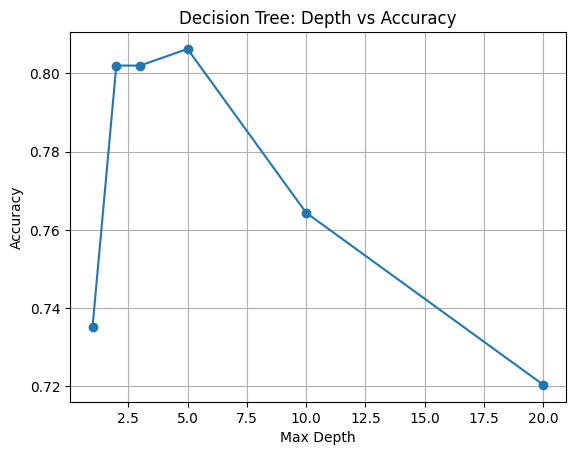

In [102]:
# 修正後のループ処理
depth_list = [1, 2, 3, 5, 10, 20]
history = []

for d in depth_list:
    print(f"\n--- 探索中: 深さ {d} ---")
    
    # 戻り値は4つになったので、4つで受け取る
    # 必要ないものは「_」で受け取って無視します
    results, models, X_val, y_val = run_classification_audition(X, y, dt_max_depth=d)
    
    # 必要な results だけ使う
    history.append({'depth': d, 'accuracy': results['DecisionTree']})

# あとはそのまま
df_history = pd.DataFrame(history)
plt.plot(df_history['depth'], df_history['accuracy'], marker='o')
plt.title('Decision Tree: Depth vs Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [103]:
# 1. バリデーションデータで予測を行う
# すでにパイプラインは fit されているので、そのまま predict できます
# ここでは「RandomForest」のパイプラインを使う例です
model = models['RandomForest'] 
y_pred = model.predict(X_val)

# 2. 予測結果をまとめた表を作る
# どこで間違えたかを特定します
results_df = X_val.copy()
results_df['Actual'] = y_val
results_df['Predicted'] = y_pred
results_df['Is_Error'] = (results_df['Actual'] != results_df['Predicted'])

# 3. 間違えたデータだけを抽出
errors = results_df[results_df['Is_Error'] == True]

print(f"全検証データ数: {len(results_df)}")
print(f"間違えた数: {len(errors)}")

# 4. 間違えたデータの平均的な特徴を見てみる
# これにより「AIが勘違いしやすい人のプロフィール」が見えてきます
print("\n--- 間違えた人たちの特徴平均値 ---")
print(errors.mean())

全検証データ数: 1409
間違えた数: 300

--- 間違えた人たちの特徴平均値 ---
SeniorCitizen                               0.223333
tenure                                     19.883333
MonthlyCharges                             71.310500
TotalCharges                             1707.594833
TotalCharges_is_null                        0.000000
Service_Count                               1.783333
Not_single_contract                         1.286667
gender_Male                                 0.466667
Partner_Yes                                 0.333333
Dependents_Yes                              0.170000
PhoneService_Yes                            0.906667
MultipleLines_No phone service              0.093333
MultipleLines_Yes                           0.400000
InternetService_Fiber optic                 0.620000
InternetService_No                          0.086667
OnlineSecurity_No internet service          0.086667
OnlineSecurity_Yes                          0.196667
OnlineBackup_No internet service            0.08666

In [105]:
df['TotalCharges'].median()

np.float64(1394.55)